# Reconstruction comparison

We want to reconstruct a given observable $f(x)$ and its derivatives from a set of data

We compare different approaches:
- parametric
- Optimized Gaussian Process
- Marginalized Gaussian Process
- GAME

In [1]:
#General
import re
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from tools.samplers_interface import SamplersInterface 

from bios    import read
from os.path import isfile
from copy    import deepcopy
from time    import time
from tqdm    import tqdm
from getdist import plots

from scipy.interpolate import interp1d
from scipy.stats       import multivariate_normal
from itertools         import repeat

from getdist import plots,loadMCSamples,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

In [2]:
possible_derivatives = ['f','int','d1','d2']

# Settings

In [3]:
Nrecon     = 20
xmin_recon = 0.
xmax_recon = 2.
x_recon = np.linspace(xmin_recon,xmax_recon,Nrecon)

x_label = r'$z$'
y_label = r'$f(z)$'

#Om = 0.32
#H0 = 67.

#theory_model = {'y': lambda x: H0*np.sqrt(Om*(1+x)**3+(1-Om))}

#fiducial = {'a0': 3,
#            'a1': -1,
#            'a2': 5,
#            'a3': -0.1}
#
#from parametric_approach.polynomial import PolynomialFit
#theory = PolynomialFit(None,None,order=3)
#theory_model = lambda x: theory.generate(x,[float(par) for par in fiducial.values()])

## Theory

In [4]:
from Cosmology.cosmo import CalcCosmology

cosmo = CalcCosmology({'H0': 67.,'omegam': 0.32})
theory_model = lambda x: {func: cosmo.results['Hubble'][func](x) for func in cosmo.results['Hubble'].keys()}

# Create or load data

Here we simulate $H(z)$ data **(To be done better)**

In [5]:
Ndata   = 50
xmin    = 0
xmax    = 2
err_fac = 10

In [6]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})
#dataset = pd.DataFrame({'x': np.linspace(xmin,xmax,Ndata)})

thvals = theory_model(dataset['x'])['f']
errors = abs(thvals)*err_fac/100
dataset['f'] = np.random.normal(thvals,errors)
dataset['f_err'] = errors

covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat.index = covmat.columns

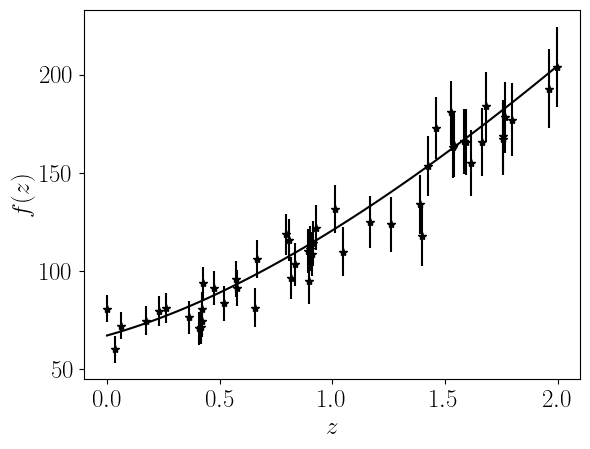

In [7]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
if theory_model != None:
    plt.plot(xplot,theory_model(xplot)['f'],color='black')
plt.errorbar(dataset['x'],dataset['f'],yerr=dataset['f_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

# Reconstructions

In [8]:
reconstructions = {}

## Polynomial approach

In [9]:
polynomial_order = 7
sampler          = 'Nautilus'

In [10]:
from parametric_approach.polynomial import PolynomialFit

In [11]:
sampler = SamplersInterface(sampler=sampler,run_options='poor',chatty=False)

In [12]:
#row = {'Info': {'Sampler': sampler}}
#
#paramtheory = PolynomialFit(dataset,covmat,order=polynomial_order)
#model_params = {'a{}'.format(ind): {'prior': [-1000,1000],
#                                    'latex': r'$a_{}$'.format(ind)} for ind in range(polynomial_order+1)}
#row['Info']['Parameters'] = model_params
#
#raw_sample = sampler.run(model_params,paramtheory.likelihood)
#sample     = paramtheory.get_derived(raw_sample,x_recon,model_params)
#row['Info']['Sample'] = sample
#
#recon,cov_reco = paramtheory.get_reconstruction(sample,x_recon)
#row['Functions']   = pd.DataFrame(recon)
#row['Covariances'] = cov_reco
#
#reconstructions['Polynomial order {}'.format(polynomial_order)] = row

In [13]:
#df = {k:v for k,v in reconstructions.items() if 'Polynomial' in k}
#
#params  = [row['Info']['Parameters'] for row in df.values()][0]
#samples = [row['Info']['Sample'] for row in df.values()]
#labels  = list(df.keys())
#
#g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)
#
#g.settings.figure_legend_frame = False
#g.settings.axes_fontsize=20
#g.settings.axes_labelsize=20
#g.settings.legend_fontsize=20
#g.settings.axis_marker_color = 'black'
#g.settings.axis_marker_ls = '--'
#g.settings.axis_marker_lw = 1
#g.settings.axis_tick_x_rotation = 45
#g.triangle_plot(samples,params,
#                legend_labels=labels,legend_loc='upper right',
#                filled=True,contour_lws=2,
#               # markers=fiducial
#               )
#g.fig.align_ylabels()
#g.fig.align_xlabels();

## Gaussian Process

In [14]:
from GaussianProcess.GPengine import GPCalculator

In [15]:
gp = GPCalculator(dataset,covmat,kernel_type='RBF')

In [16]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='MAP')

print('GP done in {:.2f} s'.format(time()-tini))

best_fit = info['Best-fit']

covmats = {'Joint': joint_cov}

for func in possible_derivatives:
    cov = joint_cov.drop(columns=[col for col in joint_cov.columns if func not in col])
    cov = cov.drop(index=[ind for ind in cov.index if func not in ind])
    covmats[func] = cov

row = {'Info': {'Values': best_fit},
       'Functions': means,
       'Covariances': covmats}

reconstructions['GP optimized'] = row

Optimizing (MAP)...
GP done in 9.06 s


In [17]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=50000,thinning=100,burn_in=0.3)

print('GP done in {:.2f} s'.format(time()-tini))

sample = info['sample']

covmats = {'Joint': joint_cov}

for func in possible_derivatives:
    cov = joint_cov.drop(columns=[col for col in joint_cov.columns if func not in col])
    cov = cov.drop(index=[ind for ind in cov.index if func not in ind])
    covmats[func] = cov

row = {'Info': {'Values': best_fit},
       'Functions': means,
       'Covariances': covmats}

reconstructions['GP marginalized'] = row

Sampling (MCMC)...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 20     | 1        | 2        | 16448    | N/A    | 10004 | -295.62  
Removed no burn in
GP done in 114.23 s


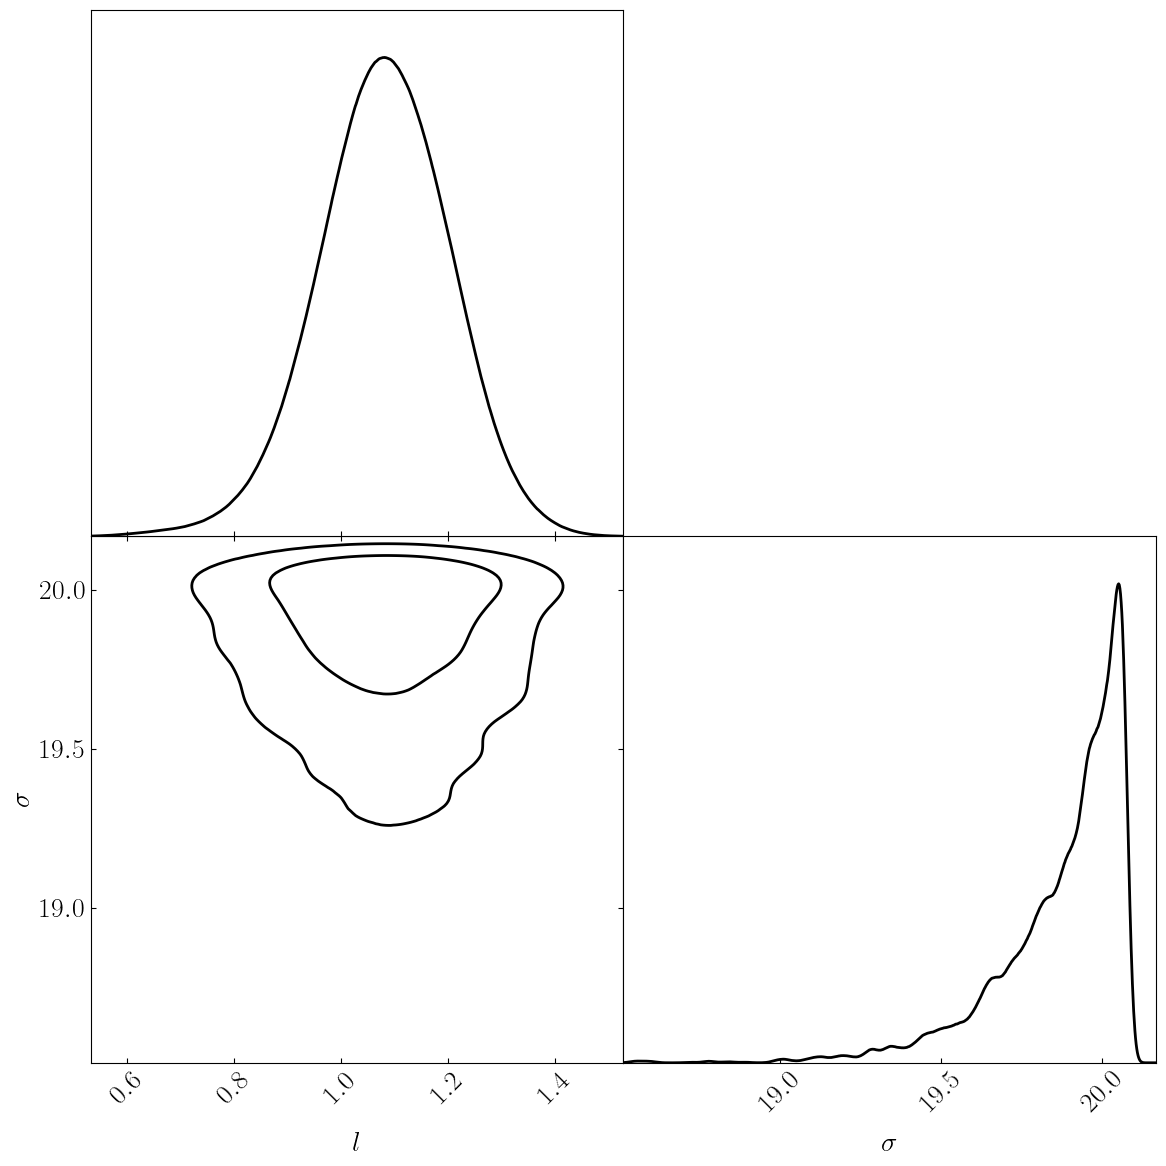

In [18]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot(sample,['l','sigma'],legend_loc='upper right',
                filled=False,contour_lws=2,
                markers=best_fit
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

# Diagnostics

In [19]:
diagnostics = pd.DataFrame(columns=['Method','Distance','Type','Function'])

## Distance from fiducial

$$d_{\rm fid}= \frac{\left(\vec{y}_{\rm recon}-\vec{y}_{\rm fid}\right)^{\rm T}\,C_{\rm recon}^{-1}\,\left(\vec{y}_{\rm recon}-\vec{y}_{\rm fid}\right)}{N_{\rm recon}}$$

In [20]:
if theory_model != None:
    for name,row in reconstructions.items():
        for func in possible_derivatives:
            print('')
            print(name,func)
            if func in row['Functions']:
                if func in theory_model(x_recon):
                    yfid   = theory_model(x_recon)[func]
                    yrecon = row['Functions'][func]
                    try:
                        invcov = np.linalg.inv(row['Covariances'][func].values)
                    except:
                        print('Not invertible matrix')
                        continue

                    chi2 = np.dot((yrecon-yfid),np.dot(invcov,(yrecon-yfid)))
                    if chi2<0:
                        print(yrecon-yfid)
    
                    df = pd.DataFrame({'Method': name,
                                       'Distance': chi2/Nrecon,
                                       'Type': r'$d_{\rm fid}$'},index=[0])
                if func == 'f':
                    df['Function'] = y_label
                elif func == 'd1':
                    df['Function'] = 'd'+y_label+'/d'+x_label
                elif func == 'd2':
                    df['Function'] = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'
                elif func == 'int':
                    df['Function'] = r'$\int$'+y_label
                    
                diagnostics = pd.concat([diagnostics,df],ignore_index=True)


GP optimized f

GP optimized int

GP optimized d1

GP optimized d2
0      8.008588
1      9.533914
2     11.211244
3     12.737979
4     13.874158
5     14.452402
6     14.372675
7     13.590000
8     12.100816
9      9.930947
10     7.126200
11     3.745515
12    -0.143802
13    -4.469350
14    -9.155872
15   -14.126836
16   -19.305615
17   -24.616419
18   -29.985090
19   -35.339806
Name: d2, dtype: float64

GP marginalized f

GP marginalized int

GP marginalized d1

GP marginalized d2


In [21]:
diagnostics

,Method,Distance,Type,Function
0,GP optimized,5.262527e+02,$d_{\rm fid}$,$f(z)$
1,GP optimized,5.262527e+02,$d_{\rm fid}$,$\int$$f(z)$
2,GP optimized,1.923685e+02,$d_{\rm fid}$,d$f(z)$/d$z$
3,GP optimized,-1.479956e+06,$d_{\rm fid}$,d$^2$$f(z)$/d$z$$^2$
4,GP marginalized,6.634348e+00,$d_{\rm fid}$,$f(z)$
5,GP marginalized,6.634348e+00,$d_{\rm fid}$,$\int$$f(z)$
6,GP marginalized,1.984933e+02,$d_{\rm fid}$,d$f(z)$/d$z$
7,GP marginalized,6.835210e+00,$d_{\rm fid}$,d$^2$$f(z)$/d$z$$^2$


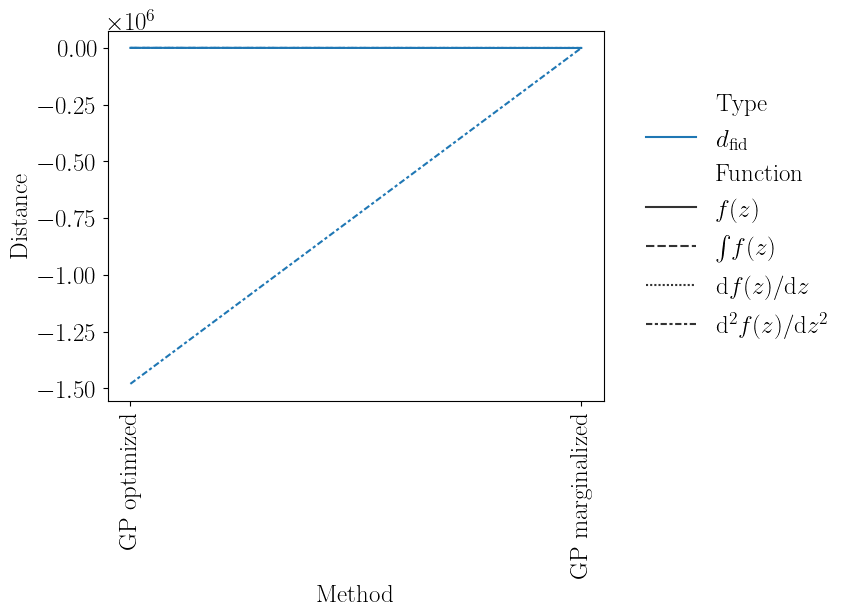

In [22]:
plt.figure()
sb.lineplot(diagnostics,x='Method',y='Distance',hue='Type',style='Function')
plt.xticks(rotation=90)
#plt.yscale('log')
plt.legend(**sidelegend);

## Distance from data

$$d_{\rm data}= \left(\vec{y}_{\rm recon}-\vec{y}_{\rm fid}\right)^{\rm T}\,C_{\rm recon}^{-1}\,\left(\vec{y}_{\rm recon}-\vec{y}_{\rm fid}\right)$$

In [23]:
#for name,row in reconstructions.items():
#    for der_order in possible_derivatives:
#        if 'y'+der_order in row['Functions']:
#            ydata  = theory_model['y'+der_order](x_recon)
#            yrecon = row['Functions']['y'+der_order]
#            invcov = np.linalg.inv(row['Covariances']['y'+der_order])
#            
#            df = pd.DataFrame({'Method': name,
#                               'Distance': np.dot((yrecon-yfid),np.dot(invcov,(yrecon-yfid))),
#                               'Type': r'$d_{\rm data}$'},index=[0])
#            
#            if der_order == '':
#                df['Function'] = y_label+'('+x_label+')'
#            elif der_order == '_p':
#                df['Function'] = 'd'+y_label+'('+x_label+')/d'+x_label
#            elif der_order == '_p':
#                df['Function'] = 'd^2'+y_label+'('+x_label+')/d^2'+x_label
#            elif der_order == '_p':
#                df['Function'] = '\int'+y_label+'('+x_label+')'
#            diagnostics = pd.concat([diagnostics,df],ignore_index=True)

# Comparison

In [24]:
dfs = []

for name,recon in reconstructions.items():
    df = pd.DataFrame(recon['Functions'])
    df['Method'] = name
    dfs.append(df)

results = pd.concat(dfs,ignore_index=True)

In [25]:
results

,x,f,d1,d2,int,f_err,d1_err,d2_err,int_err,Method
0,0.000000,69.687046,19.316241,56.913838,0.000000,1.921100,7.253528,16.775876,0.000000,GP optimized
1,0.105263,72.036675,25.333955,57.326422,7.453588,1.416491,5.778053,15.274320,0.173290,GP optimized
2,0.210526,75.020961,31.364476,57.155423,15.187911,1.111136,4.512756,13.703601,0.300176,GP optimized
3,0.315789,78.638002,37.345948,56.393915,23.269744,0.970642,3.494842,12.087307,0.395681,GP optimized
4,0.421053,82.879361,43.216160,55.042156,31.765321,0.930293,2.768005,10.457531,0.471524,GP optimized
5,0.526316,87.730067,48.913314,53.107648,40.739641,0.930342,2.357223,8.861605,0.535938,GP optimized
6,0.631579,93.168699,54.376778,50.605080,50.255784,0.941596,2.215924,7.375921,0.594071,GP optimized
7,0.736842,99.167547,59.547838,47.556169,60.374241,0.959186,2.222334,6.131328,0.648888,GP optimized
8,0.842105,105.692855,64.370424,43.989386,71.152265,0.987732,2.256014,5.337938,0.702218,GP optimized
9,0.947368,112.705133,68.791806,39.939592,82.643245,1.030097,2.249997,5.224048,0.755560,GP optimized


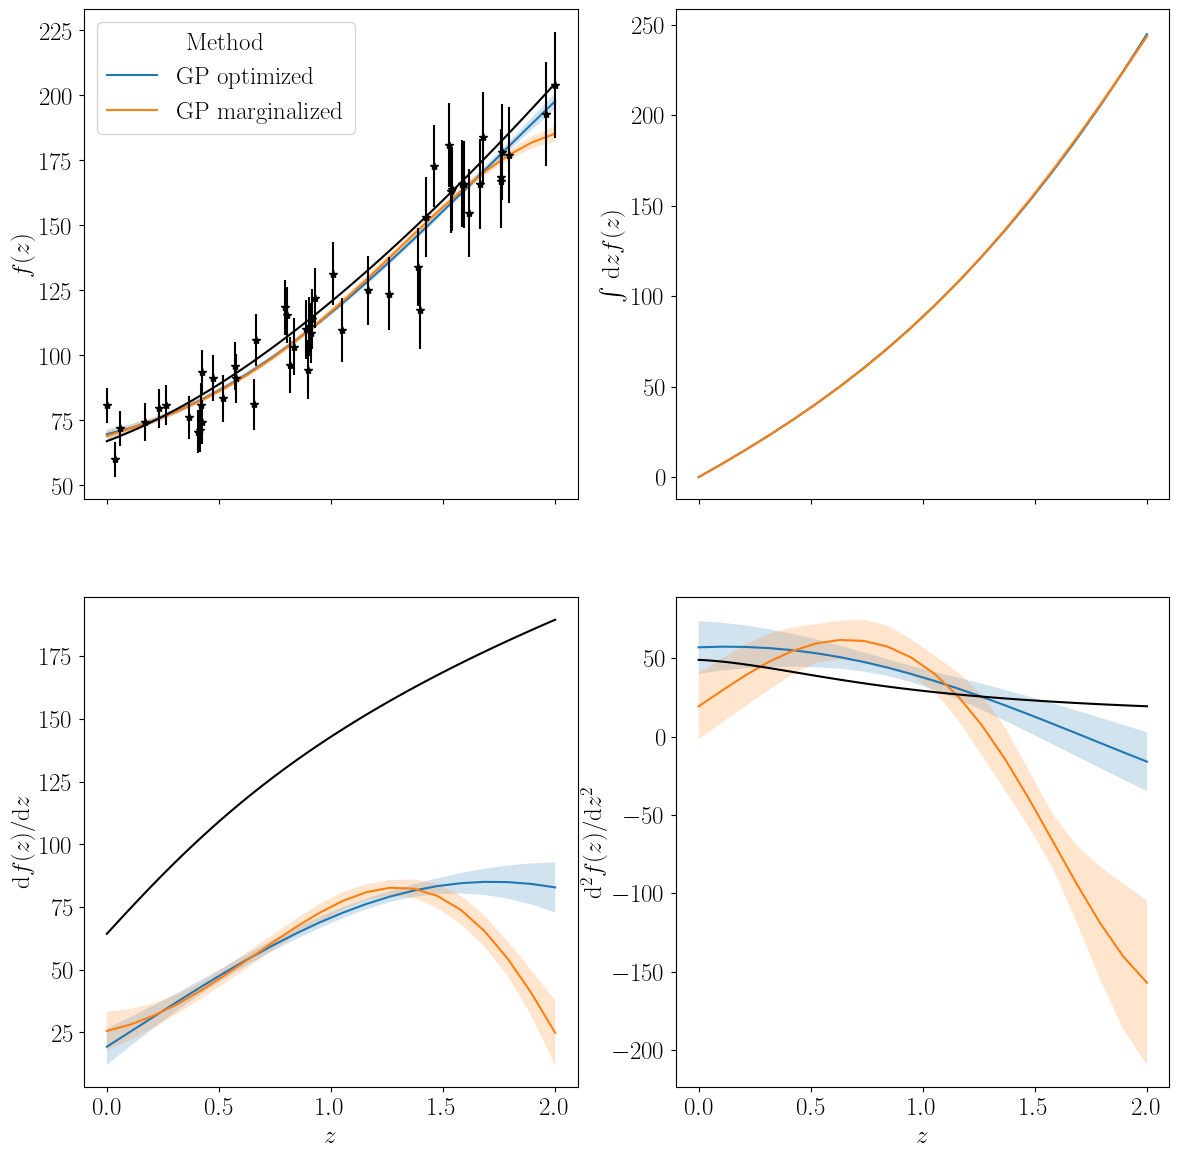

In [26]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for method in results['Method'].unique():
        df = results[results['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j])
    else:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j],legend=0)
    if theory_model != None and deriv in theory_model(xplot):
        axes[i,j].plot(xplot,theory_model(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)